In [21]:
# Initialize Otter
import otter
grader = otter.Notebook("Project_4.ipynb")

# Project 4 Choose- Your Own Dataset 

## Dataset requirements (must satisfy all)
Your dataset must be:
- **Structured tabular data** (no deep learning / images / audio)
- **Supervised**: includes a target column you will predict
- At least **5,000 instances (rows)**
- At least **10 feature columns (excluding the target)**
- This dataset cannot be any of the ones you have used in previous
projects, or the one used in the example key.
- This data **must** be uploaded along side your notebook **OR**  your notebook must include code to download your dataset.

You are allowed to source datasets from the following places:
* Kaggle: https://www.kaggle.com/datasets
* University of California – Irvine’s ML Repository: https://archive.ics.uci.edu
* Any dataset with the permission of the instructor. - Please send me a link or description when requesting

You will:
1. Explain the goal of the project and the dataset
2. Load + preprocess + split the dataset
3. Perform **PCA** and **K-means** and produce plots
4. Choose **one supervised model**, justify why you picked it, and train it
5. Describe the results, and how they relate to your goal


In [117]:
# --- Setup & Student Configuration ---
import numpy as np
import pandas as pd
import scipy,sklearn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.base import clone


from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [118]:
# Helpful for grading
print("pandas:",pd.__version__)
print("scipy:",scipy.__version__)
print("sklearn:",sklearn.__version__)
print("numpy:",np.__version__)


pandas: 2.2.3
scipy: 1.15.3
sklearn: 1.6.1
numpy: 2.4.1


In [119]:
#  https://www.kaggle.com/datasets/shree0910/online-vs-in-store-shopping-behaviour-dataset?resource=download

data = pd.read_csv('online vs store shopping dataset.csv')
data

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11784,67,151087,10.4,4,2.2,2,5,42,4,70860,...,9,9,7,2,8,7,6,Other,Tier 1,Store
11785,60,243273,6.1,10,3.0,3,2,20,14,90420,...,4,7,10,8,2,1,10,Female,Tier 2,Store
11786,53,154729,4.6,13,1.8,8,2,11,15,18700,...,5,9,1,3,4,6,1,Female,Tier 2,Store
11787,65,66116,6.2,3,1.0,1,1,31,0,61475,...,1,7,10,10,2,2,9,Other,Tier 1,Store


In [120]:
data.columns

Index(['age', 'monthly_income', 'daily_internet_hours',
       'smartphone_usage_years', 'social_media_hours',
       'online_payment_trust_score', 'tech_savvy_score',
       'monthly_online_orders', 'monthly_store_visits', 'avg_online_spend',
       'avg_store_spend', 'discount_sensitivity', 'return_frequency',
       'avg_delivery_days', 'delivery_fee_sensitivity',
       'free_return_importance', 'product_availability_online',
       'impulse_buying_score', 'need_touch_feel_score', 'brand_loyalty_score',
       'environmental_awareness', 'time_pressure_level', 'gender', 'city_tier',
       'shopping_preference'],
      dtype='object')

<!-- BEGIN QUESTION -->

# Q1 Dataset and Task Description


## (a)  Describe the motivation of the dataset and problem you want to solve. (10 points)
Your description should include a motivation and goal. The motivation should be based on the dataset. Your goal can be a 'predictive' one i.e. I would like to build a model to best forecast sales, or it could be 'inferential' one i.e.  I would like to know what variables were most import for sales last year. Please identify which specifically when describing your goal.

#  Motivation and Goal

The rapid growth of E-commerce has transformaed and change the way people buy things and how they are advertised. Since technology is advancing every day, and at a rapid rate, we have the ability to order and get almost any product delivered with a click of a button.

Because of this, we have seen online shopping become more popular every year, allowing many companies like Uber (eats), Grubhub, Doordash, etc, make a fortune out of it.

Inferential: With this dataset, I want to explore and know what varaibles are most important in predicting a consumer's shopping preference (online vs. in-person).

Our target will be shopping_preference 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## (b) Describe the variables (10 points)

What are the variables in your dataset what do they mean and why might they be useful.

**Note** Feel free describe similar variables in groups. For example *temperature*, *windspeed*, and *rain* could be grouped into 'weather conditions' please list each variable by there is no need for independent descriptions of why they are useful

In [121]:
data.columns

Index(['age', 'monthly_income', 'daily_internet_hours',
       'smartphone_usage_years', 'social_media_hours',
       'online_payment_trust_score', 'tech_savvy_score',
       'monthly_online_orders', 'monthly_store_visits', 'avg_online_spend',
       'avg_store_spend', 'discount_sensitivity', 'return_frequency',
       'avg_delivery_days', 'delivery_fee_sensitivity',
       'free_return_importance', 'product_availability_online',
       'impulse_buying_score', 'need_touch_feel_score', 'brand_loyalty_score',
       'environmental_awareness', 'time_pressure_level', 'gender', 'city_tier',
       'shopping_preference'],
      dtype='object')

In our dataset, we are working with 26 different variables, and we can categorize them by what kind of information they give us. Doing so, we can split our variables like:


#### Target Variable:

shopping_preference



#### Spending:

monthly_online_orders: Number of online orders per month

avg_online_spend: Average online purchase value

avg_store_spend

discount_sensitivity

monthly_store_visits: Store visits per month

return_frequency

impulse_buying_score



#### Tech usage:


daily_internet_hours: Hours spent online per day

smartphone_usage_years: Years of smartphone usage

social_media_hours: Daily social media usage

tech_savvy_score: Comfort with technology (1-10)

online_payment_trust_score: Trust in digital payments (1-10)



#### Personal information:

age: Age of the customer

gender: individual's gender

city_tier: individual's 

monthly_income: Monthly income in INR



#### Preferences:

free_return_importance

avg_delivery_days

need_touch_feel_score

brand_loyalty_score

time_pressure_level

product_availability_online

delivery_fee_sensitivity

environmental_awareness


<!-- END QUESTION -->

## Task 1 — Load + Preprocess + Split (Combined) (10 points)

Implement `load_preprocess_split(...)`.

**Expectations**
- Loads your dataset
- Pre-processes features as necessary for your model.
- Splits into train/test using an 80/20 split
- Returns X_train, X_test, y_train, y_test

Checks for number of points, number of features, and splits


In [133]:
from typing import Dict, Tuple, Any
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

def load_preprocess_split():
    # TO DO
    data = pd.read_csv('online vs store shopping dataset.csv')
    
    y = data['shopping_preference']
    X = data.drop(columns = ['shopping_preference'])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
    
    
    return X_train, X_test, y_train, y_test


In [134]:
X_train, X_test, y_train, y_test = load_preprocess_split()
print("X_train shape:", X_train.shape, "shape")
print("X_test shape:", X_test.shape, "shape")
print("y_train shape:", y_train.shape, "y_test shape:", y_test.shape)

X_train shape: (9431, 24) shape
X_test shape: (2358, 24) shape
y_train shape: (9431,) y_test shape: (2358,)


In [135]:
grader.check("data_loading")

data_loading results: All test cases passed!

## Task 2  Unsupervised Learning: PCA + K-means + Plot (15 poitns)

You must:
* Compute the first 2 components of a **PCA** for visualization in fit_pca_for_plot().
  
* Fit **KMeans(k=K_CLUSTERS)** on your dataset in fit_kmeans().
    * Pick a k-that appears reasonable for visualization  if possible
      
* Produce a two scatter plots with your PCA values and :
   - one with points colored by **cluster**
   - one with points colored by **target**

<!-- BEGIN QUESTION -->



In [136]:
# input_df=pd.read_csv('xg_train.csv')
# input_y=input_df['is_goal']
# input_df=input_df.drop(columns=['is_goal'])
# string_cols = input_df.select_dtypes(include=["object", "string"]).columns
# numeric_cols = input_df.select_dtypes(include=["number"]).columns

# preprocess = ColumnTransformer(
#     transformers=[
#         ("cat", OneHotEncoder(handle_unknown="ignore"), string_cols),
#         ("num", StandardScaler(), numeric_cols)],    
#         verbose_feature_names_out=False,
#         remainder="drop",
#         sparse_threshold=0,
# )

# X_processed = preprocess.fit_transform(input_df)
# df_processed = pd.DataFrame(X_processed, columns=list(preprocess.get_feature_names_out()))

#  this is from project 3, since we have string columns in our data with ints, we need to run a preprocess

In [137]:
string_cols = X_train.select_dtypes(include = ['object', 'string']).columns
numeric_cols = X_train.select_dtypes(include = ['number']).columns

preprocess = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), string_cols),
        ('num', StandardScaler(), numeric_cols)],
    verbose_feature_names_out = False,
    remainder = 'drop',
    sparse_threshold = 0,
)


def fit_pca_for_plot(X_train, X_test, random_seed: int = 42):
    
    """Returns 2D PCA embeddings for train/test."""
    
    X_train_preprocess = preprocess.fit_transform(X_train)
    X_test_preprocess = preprocess.transform(X_test)

    pca = PCA(n_components = 2)

    X_train_2d = pca.fit_transform(X_train_preprocess)
    X_test_2d = pca.transform(X_test_preprocess)

    mv1 = np.max(pca.components_[0])
    mf1 = X_train.columns[np.argmax(pca.components_[0])]

    mv2 = np.max(pca.components_[1])
    mf2 = X_train.columns[np.argmax(pca.components_[1])]

    print(f'PC1 component loading {mv1}, max var {mf1}')
    print(f'PC2 component loading {mv2}, max var {mf2}')  
    
    return X_train_2d, X_test_2d


def fit_kmeans(X_train,k=5):

    """Fits KMeans on 2D features and returns labels for train."""
    
    km = KMeans(n_clusters = k, n_init = 10)
    clusters = km.fit_predict(X_train_2d)

    return  clusters


def plot_clusters_with_target(X_2d: np.ndarray, clusters: np.ndarray, y: pd.Series):
    """Scatter plot: color by cluster, highlight by target."""
    
    sns.scatterplot(x = X_2d[:, 0], y = X_2d[:, 1], hue = clusters, s = 5)
    
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.show()

    sns.scatterplot(x = X_2d[:, 0], y = X_2d[:, 1], hue = y, s = 5)

    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.show()
    

PC1 component loading 0.46166503079918764, max var avg_store_spend
PC2 component loading 0.5086731011896273, max var delivery_fee_sensitivity


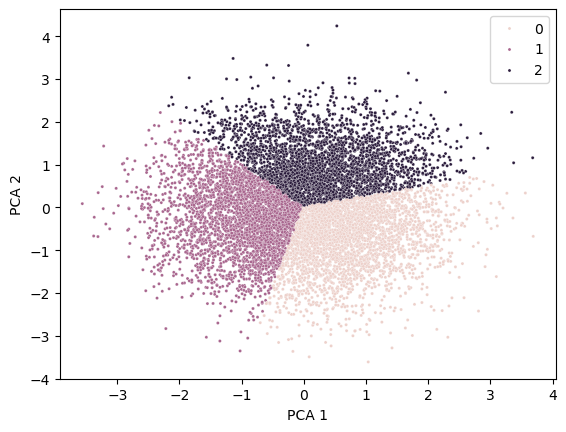

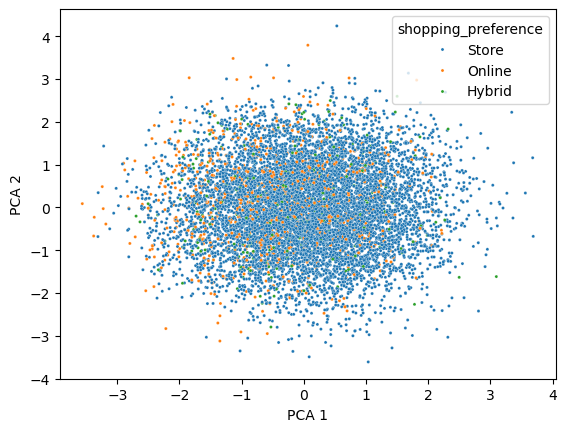

In [138]:
X_train_2d, X_test_2d = fit_pca_for_plot(X_train, X_test)
train_clusters = fit_kmeans(X_train, k=3)
plot_clusters_with_target(X_train_2d, train_clusters, y_train)

<!-- END QUESTION -->

## Unsupervised Questions
Answer the following questions based on your results above.

<!-- BEGIN QUESTION -->

a) How do the clusters compare with your target. Is K-means clustering useful for this problem. (5 points)

My target ratio is very different from the clusters that are formed by K-means (they do not align well). In the cluster graph, the points are clearly seperated into 3 groups. In teh 2nd graoh, when they are labeled by the target variable, it is all mixed and very difficult to read. This means that K-means may not be a very useful assumption for this dataset, or not very useful for predicting the target variable.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

b) What are the biggest variables contributing to the first two components of the PCA.  (5 points)

The biggest variables contributing to the first two components of the PCA are avg_store_spend and delivery_fee_sensitivity

<!-- END QUESTION -->

# Task 3 - Train Model 
 In this task you should
 1. Select a model that matches your goal, and explain why it is a good fit.
 2. Implement
     * Implement that model in build_model
     * Write an evaluation function that is appropriate for your model and task.
     * train and evaluate the model in train_eval() (you may use dim reduction here too if necessary!)
 3. Describe how these results helps you solve the goal you are trying to preform
    
**Note:** please add any necessary code needed to evaluate results in the functions below this could include ploting a decision tree, making a scatter plot of y_true vs. y_pred, plotting loss curves, or anything else you need to answer 3. 

<!-- BEGIN QUESTION -->

# Model Justification
1. What model did you select and why is it a good fit for your goal (15 - points)

Because our target variable is categorical, where we are trying to predict what features are most important when someone is decidng how to do their shopping (shopping_preference: online, store, hybrid), I am going to use a decision tree to help me decide on a shopping preference. The reason is because a decision tree works well for multi-classification problems where we have 3 different outcomes on our target. Another reason why is that decision trees are easy to interpret and is a simple model that clearly explains how decisions are made. On top of that, it shows where the splits are made, so we can see what variables have a bigger impact on decision making.  

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

# Implementation - (10 points)

In [191]:
from sklearn import tree
from sklearn.metrics import r2_score

def build_model():

    model = tree.DecisionTreeClassifier(max_depth = 3)

    return model
    

def evaluate_predictions(y_true, y_pred) -> dict:

    #print('Accuracy',round((clf.predict(X_test)==y_test).mean()*100,2),"%")
    accuracy = float((y_pred == y_true).mean())
    metrics = {'accuracy': accuracy}

    return metrics

    
def train_eval(X_train, X_test, y_train, y_test ):
    
    X_train_p = preprocess.fit_transform(X_train)
    X_test_p = preprocess.transform(X_test)
    
    plt.figure(figsize = (24, 12), dpi = 200)
    
    model = build_model()
    model.fit(X_train_p, y_train)

    names = preprocess.get_feature_names_out()    # AttributeError: 'numpy.ndarray' object has no attribute 'columns'
    
    tree.plot_tree(model, filled = True, feature_names = names)
    plt.show()
    
    pred = model.predict(X_test_p)
    metrics = evaluate_predictions(y_test, pred)

    return metrics, model.classes_


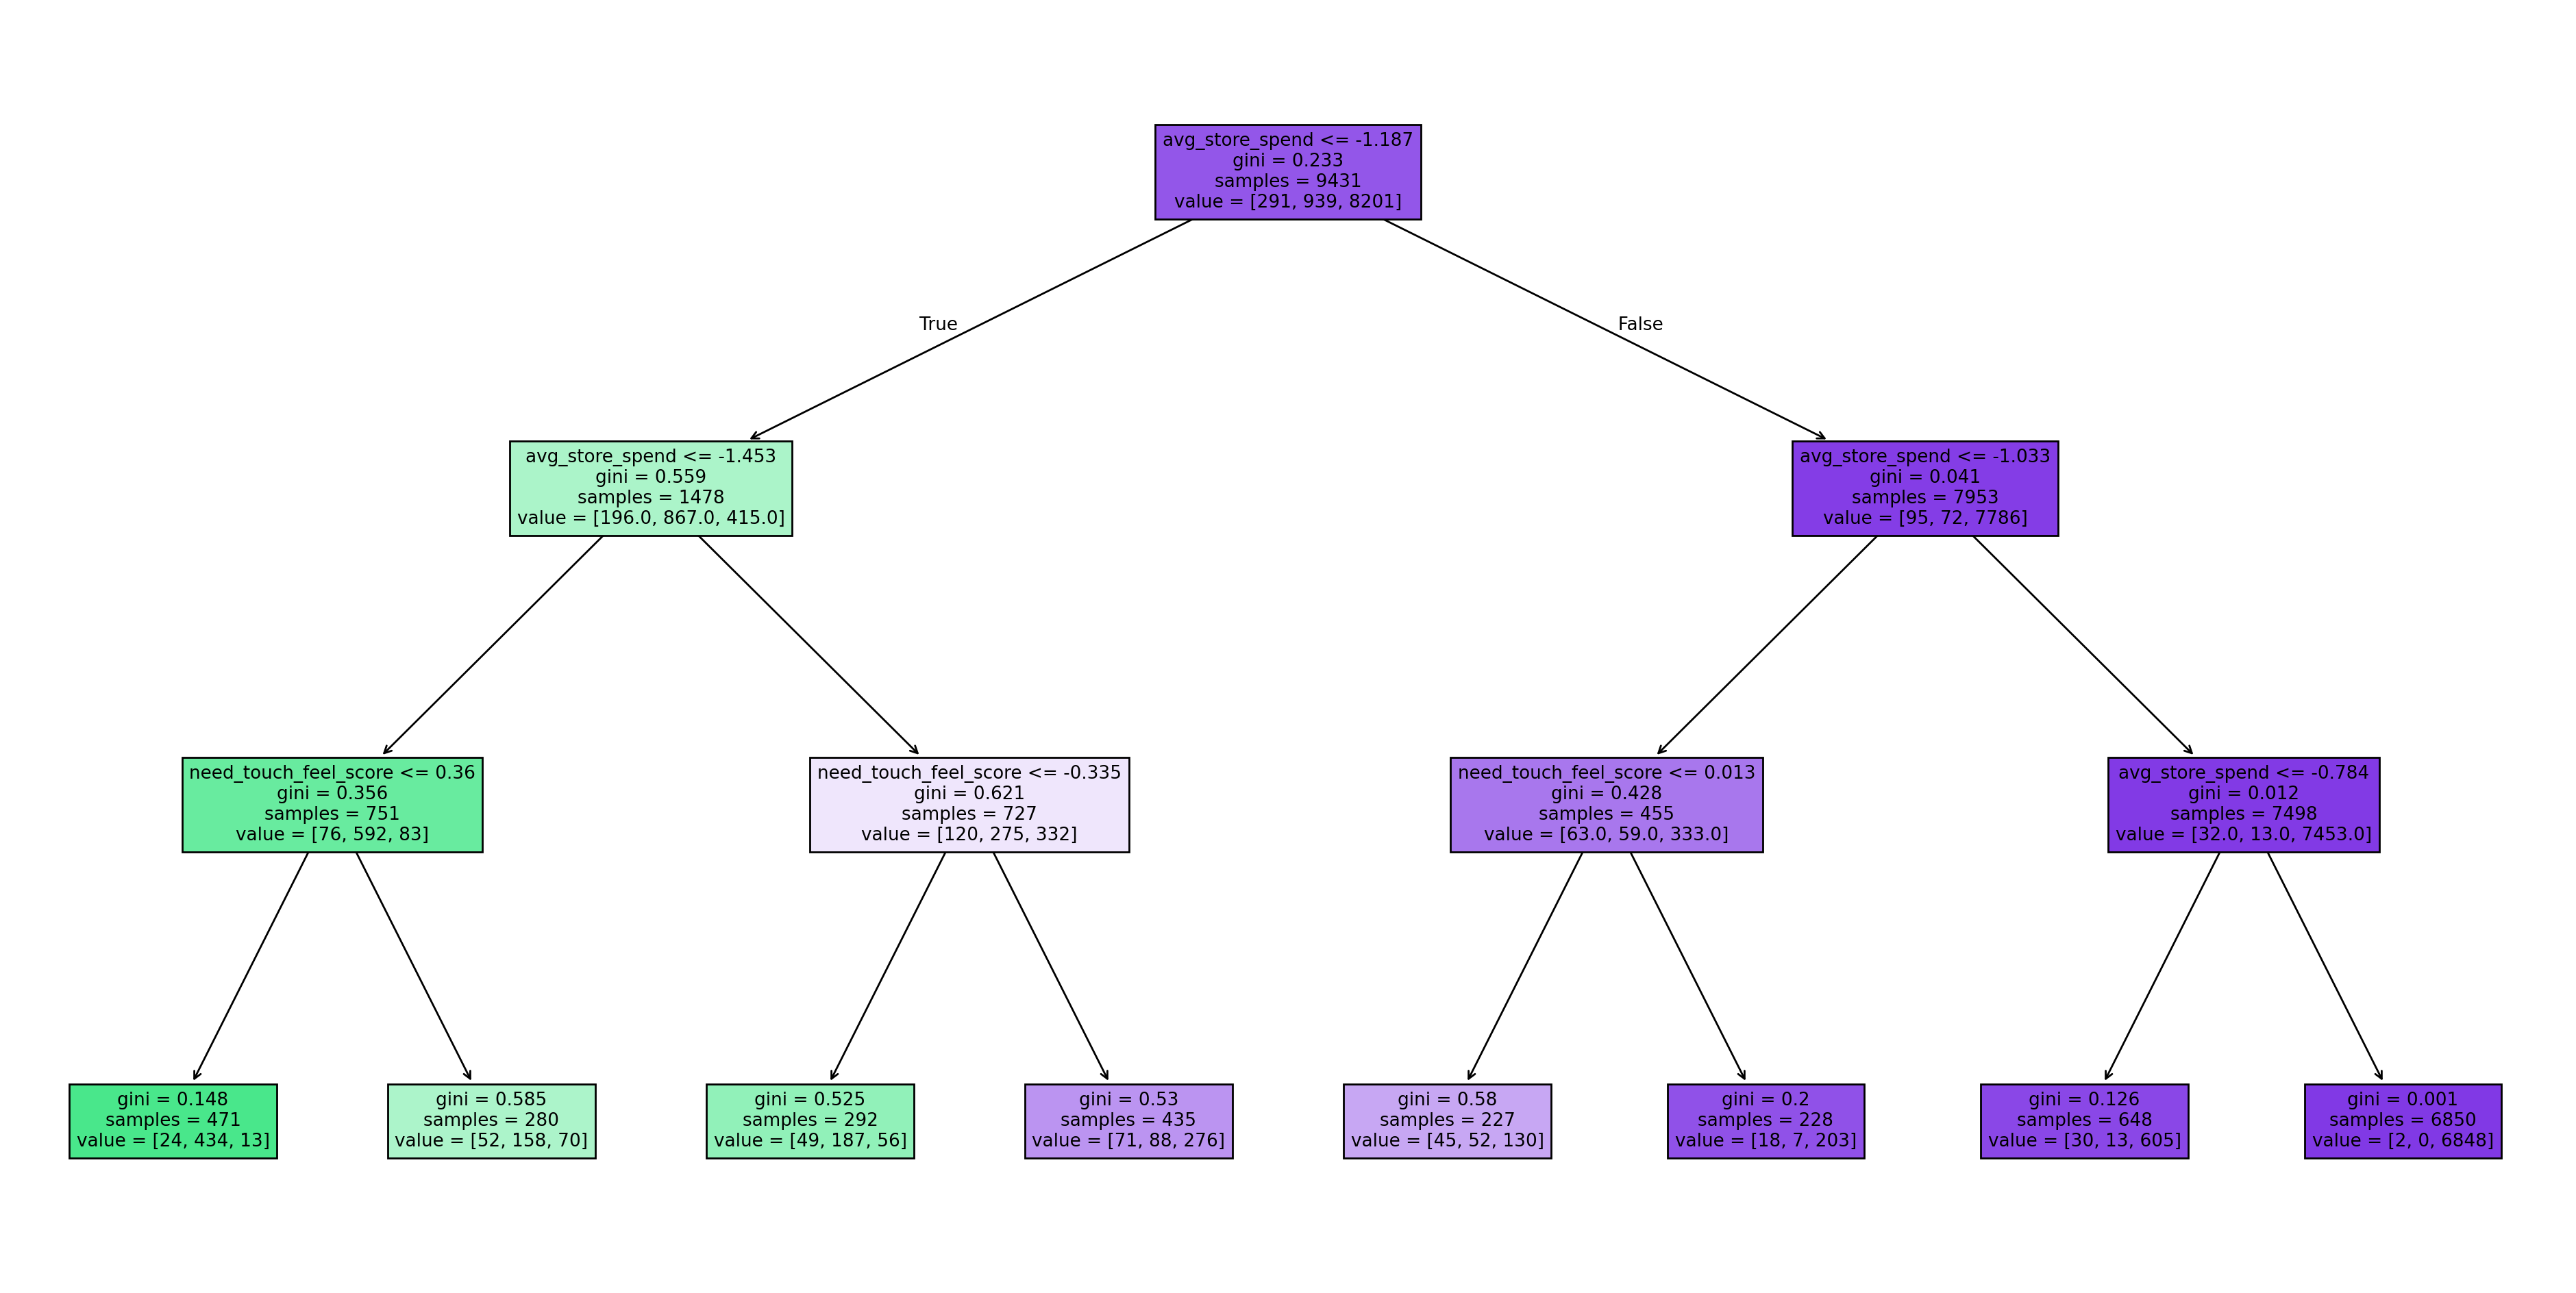

({'accuracy': 0.9355385920271416},
 array(['Hybrid', 'Online', 'Store'], dtype=object))

In [192]:
results = train_eval(
    X_train, X_test, y_train, y_test
)
results

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

# Results (20 points)
Please explain how your plots and results above relate to or solve your initial goal. Include a description of the quality of your model, and your conclusions.

My initial goal was to deteremine what variables/values had a high importance to determining the classification outcome (why people chose online or in-person shopping). My decision tree provides a strong prediction of the target (accuracy = ~93%). We can see in our model that avg_store_spend and need_touch_feel_score have a a strong role in determining the classification outcome. With our values, avg_store_spend has the highest role and suggests that the amount that someone spends on average is a big predictor on if they are doing that online or in-person. From there, being able to actually feel and touch the product plays a big role, since most consumers want to make sure what they are buying is actually worth it, and it fits their standard. In our tree itself, we can see that people who have a lower average store spending and lower need touch feel score tend to do more in person shopping, whereas people who a higher average store spending and lower need touch feel score will move over to the online shopping. This model highly predicts the result if someone will decide to buy online or in person, making decision tree classifier a good model to show our data. 

<!-- END QUESTION -->

